# 🚗 Car Price Prediction

A machine learning project that predicts used car prices from features such as make, model, year,
mileage, engine size, fuel type, and transmission.

The notebook covers the full workflow:

1. Exploratory Data Analysis (EDA)
2. Data Cleaning & Outlier Removal
3. Feature Encoding & Scaling
4. Model Training — **Linear Regression**, **Ridge Regression**, and **Lasso Regression**
5. Model Evaluation & Comparison

---


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    PolynomialFeatures,
    OneHotEncoder,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    root_mean_squared_error,
)

# Consistent plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Dataset

The dataset (`Car_Price_Prediction.csv`) is expected to sit in the same directory as this notebook,
which is the case when the repository is cloned as-is.

In [2]:
df = pd.read_csv('Car_Price_Prediction.csv')
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   str    
 1   Model         1000 non-null   str    
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   str    
 6   Transmission  1000 non-null   str    
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [4]:
df.shape

(1000, 8)

In [5]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


### 3.2 Column Types

In [6]:
num_cols = list(df.select_dtypes(include=np.number).columns)
cat_cols = list(df.select_dtypes(include='object').columns)

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Year', 'Engine Size', 'Mileage', 'Price']
Categorical columns: ['Make', 'Model', 'Fuel Type', 'Transmission']


/tmp/ipykernel_538/2110564150.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(df.select_dtypes(include='object').columns)


### 3.3 Distribution of Numerical Features (Boxplots)

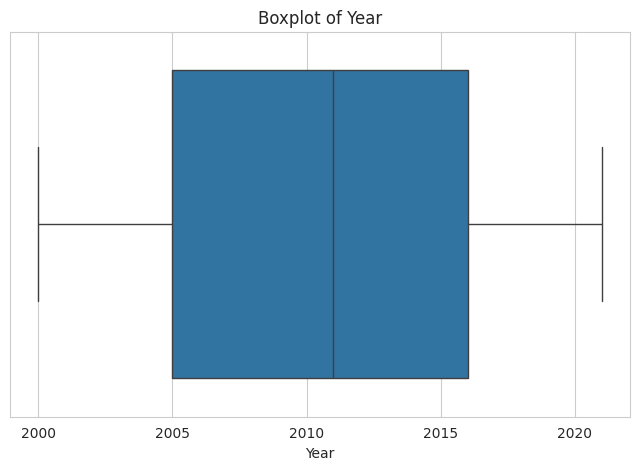

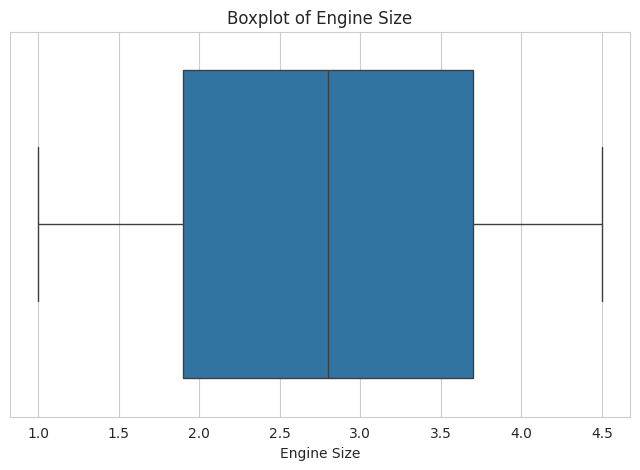

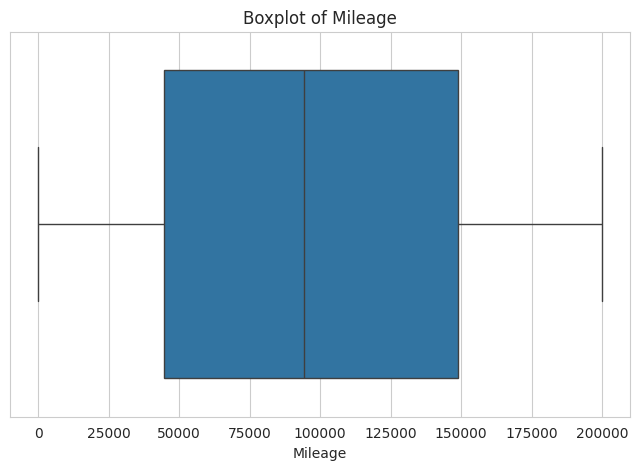

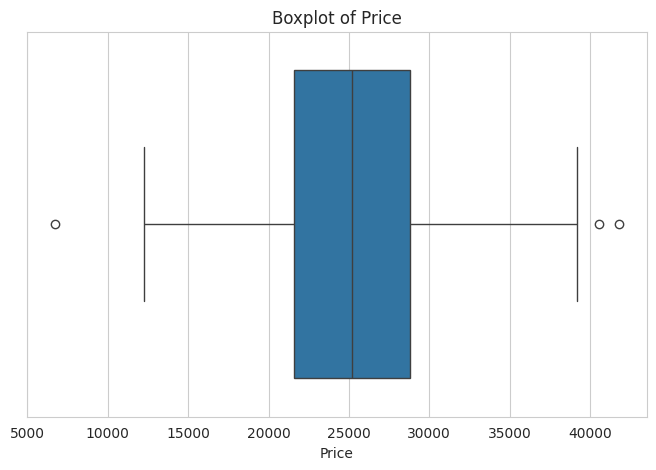

In [7]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### 3.4 Relationship Between Numerical Features and Price

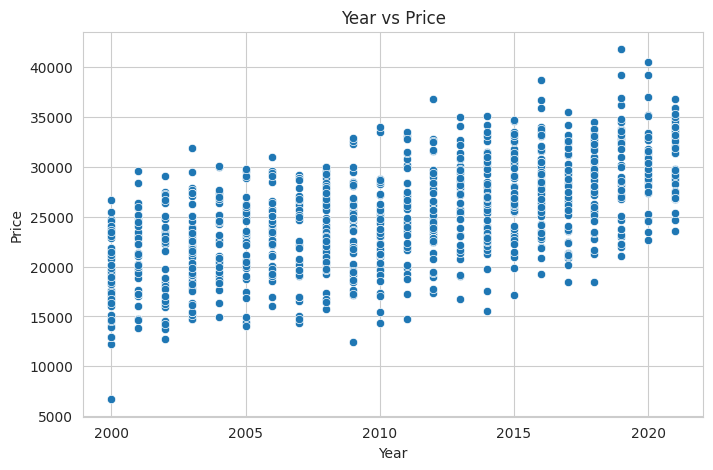

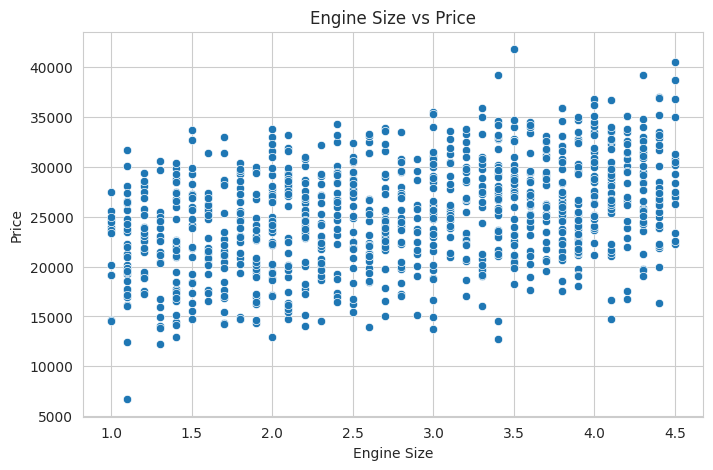

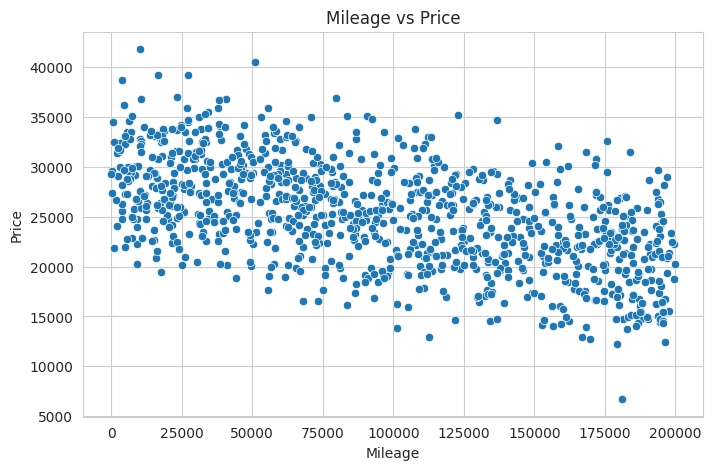

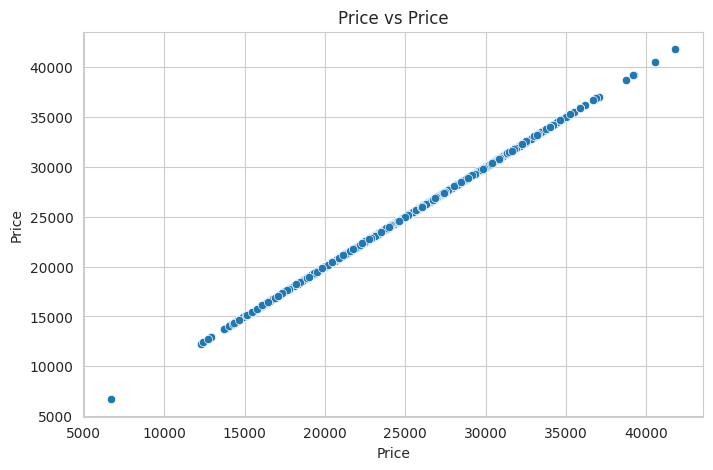

In [8]:
for col in num_cols:
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'{col} vs Price')
    plt.show()

### 3.5 Correlation Heatmap

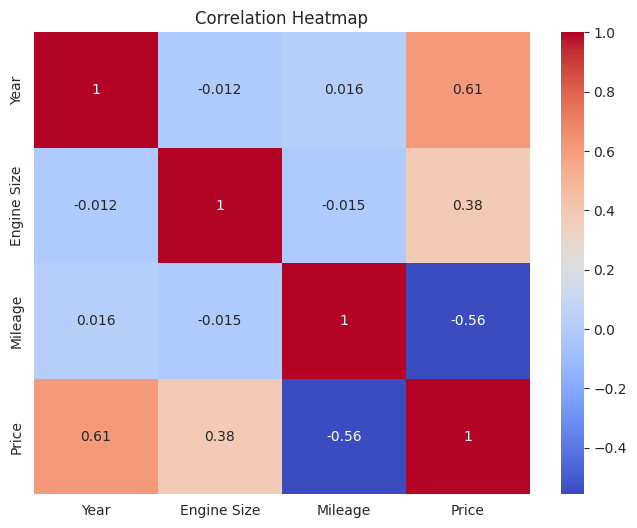

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 3.6 Distribution of Categorical Features

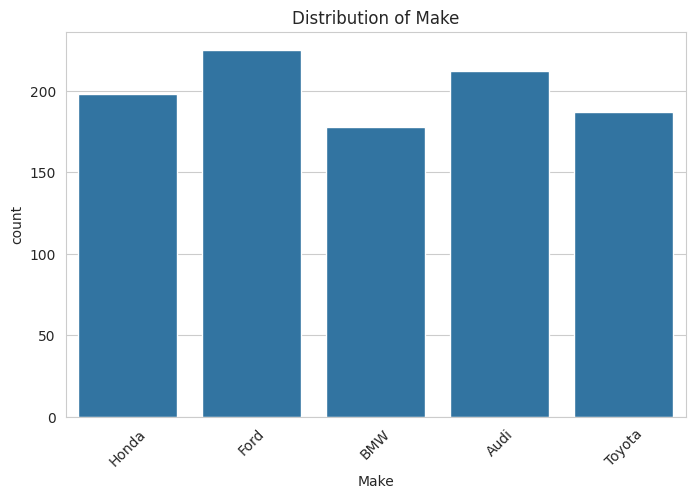

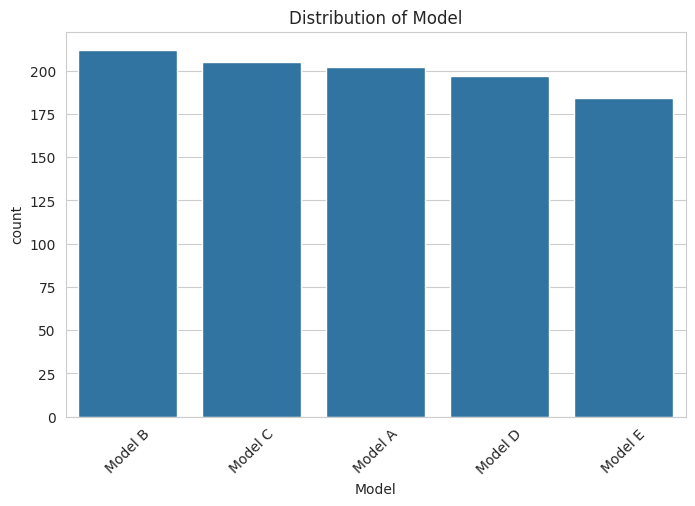

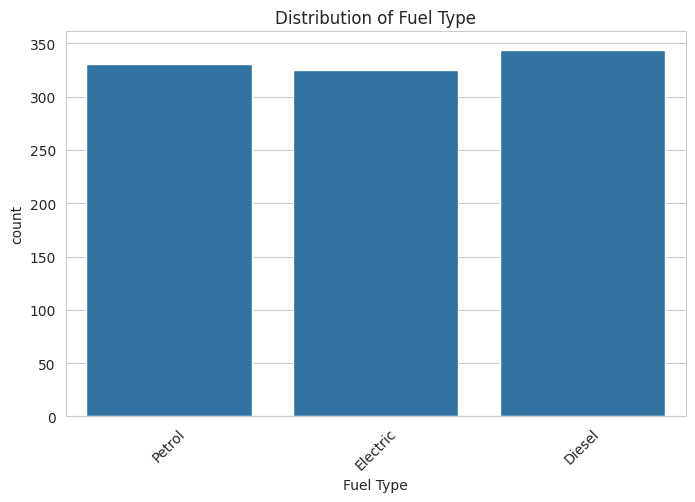

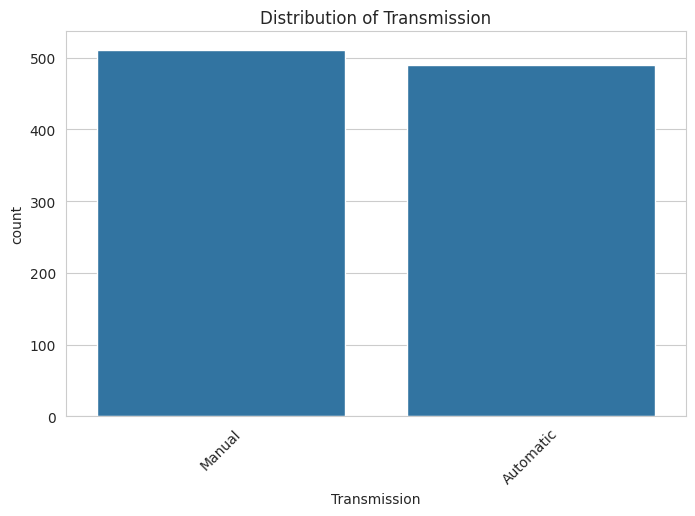

In [10]:
for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

## 4. Outlier Removal

Outliers in the target variable (`Price`) are detected and removed using the IQR (Interquartile Range) method.

In [11]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
df = df.loc[~df.index.isin(outliers.index)]

outliers

Lower Bound : 10760.142462737595
Upper Bound : 39634.10488078541


,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
133,BMW,Model A,2019,3.5,10315,Electric,Manual,41780.504635
295,Ford,Model C,2020,4.5,50886,Petrol,Manual,40538.382064
981,Audi,Model B,2000,1.1,181142,Diesel,Automatic,6704.953524


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          997 non-null    str    
 1   Model         997 non-null    str    
 2   Year          997 non-null    int64  
 3   Engine Size   997 non-null    float64
 4   Mileage       997 non-null    int64  
 5   Fuel Type     997 non-null    str    
 6   Transmission  997 non-null    str    
 7   Price         997 non-null    float64
dtypes: float64(2), int64(2), str(4)
memory usage: 70.1 KB


### 4.1 Price Distribution by Model (Post Cleaning)

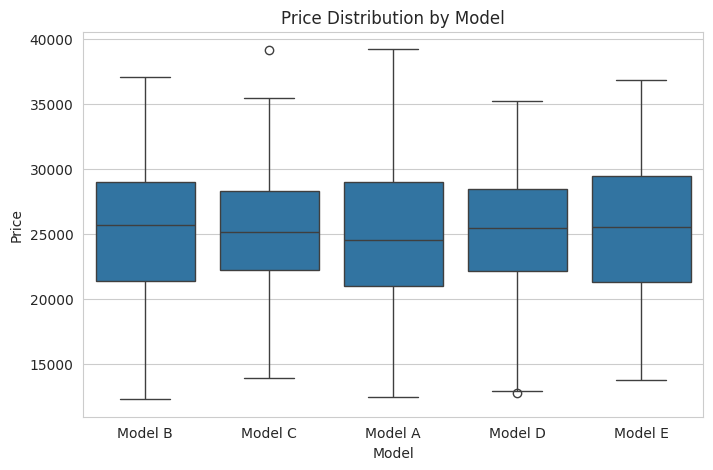

In [13]:
sns.boxplot(x='Model', y='Price', data=df)
plt.title('Price Distribution by Model')
plt.show()

In [14]:
df['Model'].unique()

<StringArray>
['Model B', 'Model C', 'Model A', 'Model D', 'Model E']
Length: 5, dtype: str

### 4.2 Missing Value Check

In [15]:
df.loc[df.isnull().any(axis=1)]

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price


## 5. Feature Encoding

- `Transmission` → binary-mapped (`Manual` = 0, `Automatic` = 1)
- `Model` → ordinal-mapped
- `Fuel Type` and `Make` → one-hot encoded

### 5.1 Encode `Transmission`

In [16]:
df['Transmission'] = df['Transmission'].map({'Manual': 0, 'Automatic': 1})

### 5.2 Encode `Model`

In [17]:
df['Model'] = df['Model'].map({'Model A': 1, 'Model B': 2, 'Model C': 3, 'Model D': 4, 'Model E': 5})

### 5.3 One-Hot Encode `Fuel Type`

In [18]:
encoder = OneHotEncoder()

encoded = encoder.fit_transform(df[['Fuel Type']])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(['Fuel Type']),
    index=df.index
)

df = pd.concat([df, encoded_df], axis=1)
df.drop('Fuel Type', axis=1, inplace=True)

### 5.4 One-Hot Encode `Make`

In [19]:
encoder = OneHotEncoder()

encoded = encoder.fit_transform(df[['Make']])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(['Make']),
    index=df.index
)

df = pd.concat([df, encoded_df], axis=1)
df.drop('Make', axis=1, inplace=True)

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 997 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Model               997 non-null    int64  
 1   Year                997 non-null    int64  
 2   Engine Size         997 non-null    float64
 3   Mileage             997 non-null    int64  
 4   Transmission        997 non-null    int64  
 5   Price               997 non-null    float64
 6   Fuel Type_Diesel    997 non-null    float64
 7   Fuel Type_Electric  997 non-null    float64
 8   Fuel Type_Petrol    997 non-null    float64
 9   Make_Audi           997 non-null    float64
 10  Make_BMW            997 non-null    float64
 11  Make_Ford           997 non-null    float64
 12  Make_Honda          997 non-null    float64
 13  Make_Toyota         997 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 116.8 KB


In [21]:
encoded_feat = list(df.select_dtypes(include='number').columns)
encoded_feat.remove('Price')
encoded_feat

['Model',
 'Year',
 'Engine Size',
 'Mileage',
 'Transmission',
 'Fuel Type_Diesel',
 'Fuel Type_Electric',
 'Fuel Type_Petrol',
 'Make_Audi',
 'Make_BMW',
 'Make_Ford',
 'Make_Honda',
 'Make_Toyota']

## 6. Feature Selection & Train/Test Split

For this notebook, the model is trained on the core numerical predictors: `Year`, `Mileage`, and `Engine Size`.

In [22]:
X = df[['Year', 'Mileage', 'Engine Size']]
y = df['Price']

for col in X.columns:
    print(col, X[col].isna().sum())

Year 0
Mileage 0
Engine Size 0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Feature Scaling

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Polynomial Features (Optional)

Second-degree polynomial features are generated here for experimentation. They are not used by the
models trained below, but are kept available for further extensions of this project.

In [25]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 9. Model Training & Evaluation

A small helper function is used to keep evaluation consistent across all three models.

In [26]:
def evaluate_model(name, y_true, y_pred):
    """Compute and print standard regression metrics for a model's predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R²  :", r2 * 100)

    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


def plot_predictions(y_true, y_pred, title):
    minimum = min(y_true.min(), y_pred.min())
    maximum = max(y_true.max(), y_pred.max())

    plt.scatter(y_true, y_pred, edgecolors='#3874FF', color='#A5E9DD')
    plt.plot([minimum, maximum], [minimum, maximum], color='#000000')

    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    plt.show()


results = []

### 9.1 Linear Regression

In [27]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

**Sample predictions**

In [28]:
result_lr = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred_lr})
result_lr.sample(5)

,y_test,y_pred
214,23445.912505,21917.379008
550,29955.254017,27743.615987
916,34637.417286,32132.301692
211,33193.209108,33075.478106
209,27428.210493,26390.980307


**Evaluation — Linear Regression**

In [29]:
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

--- Linear Regression ---
MAE : 1738.5148570374831
MSE : 4634769.492435288
RMSE: 2152.8514794187004
R²  : 84.35086200995629


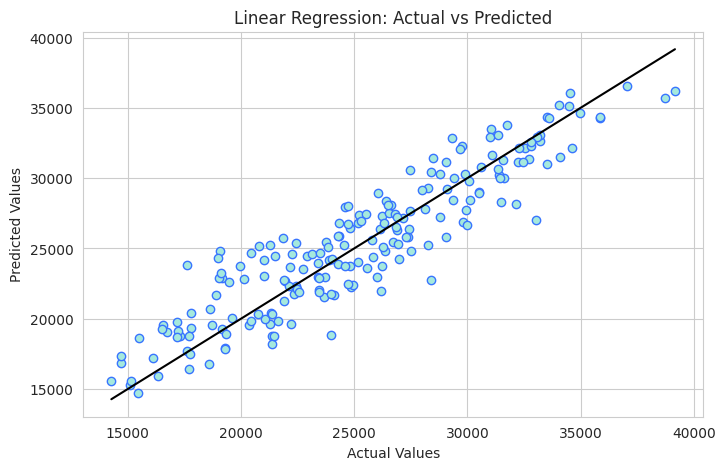

In [30]:
plot_predictions(y_test, y_pred_lr, 'Linear Regression: Actual vs Predicted')

### 9.2 Ridge Regression

Ridge applies L2 regularization, shrinking coefficients to reduce overfitting while keeping all features.

In [31]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

**Sample predictions**

In [32]:
result_ridge = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred_ridge})
result_ridge.sample(5)

,y_test,y_pred
434,23688.754765,21520.321976
913,20380.338621,19556.364711
741,18596.853815,16824.881393
866,31056.064002,33516.710450
595,17773.492240,17518.104202


**Evaluation — Ridge Regression**

In [33]:
results.append(evaluate_model('Ridge Regression', y_test, y_pred_ridge))

--- Ridge Regression ---
MAE : 1738.4181258301705
MSE : 4634064.816102905
RMSE: 2152.6878120393826
R²  : 84.35324132508335


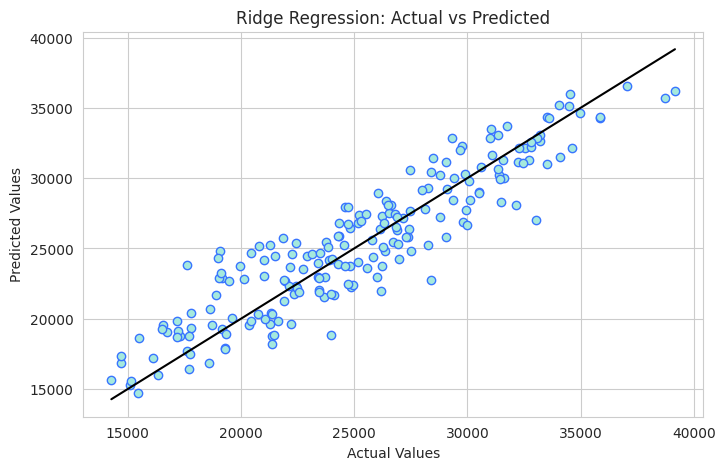

In [34]:
plot_predictions(y_test, y_pred_ridge, 'Ridge Regression: Actual vs Predicted')

### 9.3 Lasso Regression

Lasso applies L1 regularization, which can shrink some coefficients to exactly zero — effectively
performing feature selection.

In [35]:
lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

**Sample predictions**

In [36]:
result_lasso = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred_lasso})
result_lasso.sample(5)

,y_test,y_pred
211,33193.209108,33072.255786
293,26006.433808,22962.639807
308,21915.635472,22760.982836
664,28119.566928,27787.482318
281,24610.467746,27946.392192


**Evaluation — Lasso Regression**

In [37]:
results.append(evaluate_model('Lasso Regression', y_test, y_pred_lasso))

--- Lasso Regression ---
MAE : 1738.5130851715503
MSE : 4634615.339463434
RMSE: 2152.815677075823
R²  : 84.35138250210417


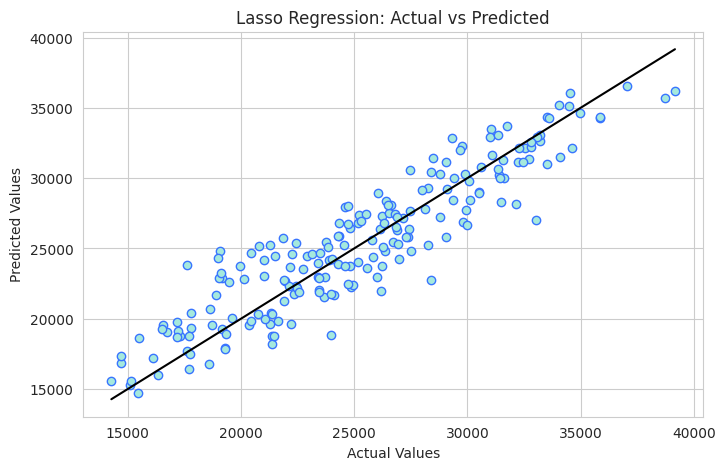

In [38]:
plot_predictions(y_test, y_pred_lasso, 'Lasso Regression: Actual vs Predicted')

## 10. Model Comparison

Side-by-side comparison of all three models on the held-out test set.

In [39]:
results_df = pd.DataFrame(results).set_index('Model')
results_df

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,1738.514857,4.634769e+06,2152.851479,0.843509
Ridge Regression,1738.418126,4.634065e+06,2152.687812,0.843532
Lasso Regression,1738.513085,4.634615e+06,2152.815677,0.843514


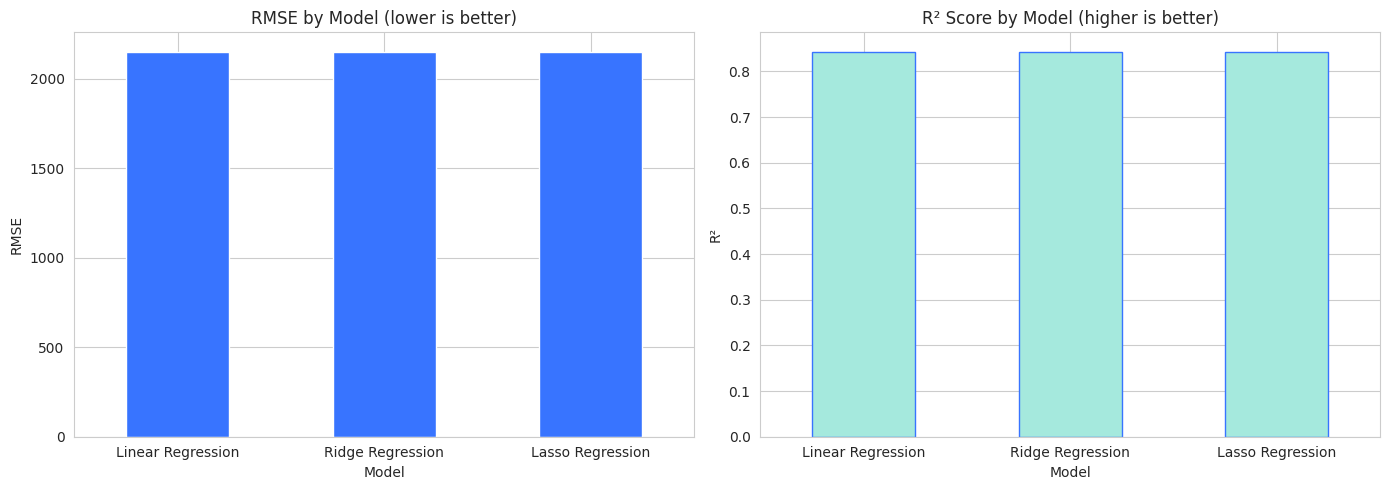

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['RMSE'].plot(kind='bar', ax=axes[0], color='#3874FF')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=0)

results_df['R2'].plot(kind='bar', ax=axes[1], color='#A5E9DD', edgecolor='#3874FF')
axes[1].set_title('R² Score by Model (higher is better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 11. Conclusion

- All three linear models (Linear, Ridge, Lasso) were trained on the same scaled features
  (`Year`, `Mileage`, `Engine Size`) and evaluated on an identical test split for a fair comparison.
- The comparison table and charts above summarize which model generalizes best on this dataset
  (see `results_df`, and the RMSE / R² bar charts).
- Ridge and Lasso are expected to perform similarly to plain Linear Regression on this dataset since
  it has few, largely uncorrelated features — their regularization benefits become more apparent with
  higher-dimensional or highly correlated feature sets (e.g. including the one-hot encoded columns).
- **Possible next steps:** train on the full encoded feature set (including one-hot `Make`/`Fuel Type`
  columns), tune `alpha` for Ridge/Lasso via cross-validation, and compare against the imported
  `XGBRegressor` for a non-linear baseline.
